# Latency Analysis — MoveEnet_OFK

Analysis notebook for the latency benchmark at nominal 50 Hz.

Primary cross-method metric: `method_latency_ms`.

Secondary diagnostics: `service_latency_ms`; EventPointPose `server_processing_ms`; MoveEnetOFK dataset-time fusion delay.

Rules: discard the first 10 valid pose outputs of every run; treat each sequence/run as the statistical unit; inference-level distributions are descriptive only; `method_latency_ms > 20 ms` is a computational-budget exceedance, not a measured dropped-frame/deadline-miss rate.


In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    print("scipy not available: paired tests will be skipped.")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RESULTS_ROOT = Path("/data/MoveEnet_OFK_results/Latency")
SESSION = "latency_50hz_main"
# For development only: SESSION = "smoke_H01"
SESSION_ROOT = RESULTS_ROOT / SESSION
RUN_MANIFEST = SESSION_ROOT / "run_manifest.csv"
DROP_FIRST_VALID = 10
BUDGET_MS = 20.0

print("Session root :", SESSION_ROOT)
print("Manifest     :", RUN_MANIFEST)
print("Exists       :", SESSION_ROOT.exists())


Session root : /data/MoveEnet_OFK_results/Latency/latency_50hz_main
Manifest     : /data/MoveEnet_OFK_results/Latency/latency_50hz_main/run_manifest.csv
Exists       : True


## 1. Load run manifest

The runner writes one row per model execution. This is the authoritative index for dataset, sample, model, execution order, latency CSV path and run status.


In [2]:
if not RUN_MANIFEST.is_file():
    raise FileNotFoundError(
        f"Run manifest not found: {RUN_MANIFEST}\n"
        "Set SESSION to the correct experiment folder."
    )

manifest = pd.read_csv(RUN_MANIFEST)
print("Manifest rows:", len(manifest))
display(manifest.head())

if "status" in manifest.columns:
    print("\nRun status counts:")
    display(manifest["status"].value_counts(dropna=False).rename("count").to_frame())

required = {"dataset", "sample_id", "model", "latency_csv"}
missing = required - set(manifest.columns)
if missing:
    raise ValueError(f"Missing manifest columns: {sorted(missing)}")


Manifest rows: 84


,dataset,sample_id,subject,sequence,camera,motion_class,model,order_id,order_position,env_mode,start_time,end_time,wall_seconds,gpu_temp_start_c,gpu_temp_end_c,exit_code,status,latency_rows,latency_csv,run_log
0,h36m,H01,S9,Discussion_1,cam2,mixed,movenet,H0,1,system,2026-08-21T15:06:01+00:00,2026-08-21T15:08:15+00:00,135,47,63,0,OK,5778,/data/MoveEnet_OFK_results/Latency/latency_50h...,/data/MoveEnet_OFK_results/Latency/latency_50h...
1,h36m,H01,S9,Discussion_1,cam2,mixed,moveenetofk,H0,2,system,2026-08-21T15:08:36+00:00,2026-08-21T15:11:16+00:00,160,60,69,0,OK,5778,/data/MoveEnet_OFK_results/Latency/latency_50h...,/data/MoveEnet_OFK_results/Latency/latency_50h...
2,h36m,H01,S9,Discussion_1,cam2,mixed,openpose,H0,3,system,2026-08-21T15:11:36+00:00,2026-08-21T15:17:09+00:00,333,65,73,0,OK,5873,/data/MoveEnet_OFK_results/Latency/latency_50h...,/data/MoveEnet_OFK_results/Latency/latency_50h...
3,h36m,H01,S9,Discussion_1,cam2,mixed,yolo,H0,4,venv,2026-08-21T15:17:30+00:00,2026-08-21T15:19:11+00:00,101,66,68,0,OK,5873,/data/MoveEnet_OFK_results/Latency/latency_50h...,/data/MoveEnet_OFK_results/Latency/latency_50h...
4,h36m,H07,S11,Discussion_2,cam2,mixed,yolo,H2,1,venv,2026-08-21T15:19:31+00:00,2026-08-21T15:20:13+00:00,42,63,66,0,OK,2198,/data/MoveEnet_OFK_results/Latency/latency_50h...,/data/MoveEnet_OFK_results/Latency/latency_50h...



Run status counts:


,count
status,
OK,84


## 2. Helpers

A valid latency row requires `valid_pose == 1` and finite service/method latency. For EventPointPose, `status == OK` is also required. The first 10 valid outputs are removed independently for every run.


In [3]:
def finite_series(s):
    return pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)

def percentile(x, q):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.percentile(x, q)) if len(x) else np.nan

def metric_summary(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if not len(x):
        return dict(n=0, mean=np.nan, median=np.nan, std=np.nan, p95=np.nan, p99=np.nan, min=np.nan, max=np.nan)
    return dict(
        n=len(x), mean=float(np.mean(x)), median=float(np.median(x)),
        std=float(np.std(x, ddof=1)) if len(x)>1 else 0.0,
        p95=percentile(x,95), p99=percentile(x,99),
        min=float(np.min(x)), max=float(np.max(x))
    )

def normalize_model_name(x):
    s = str(x).strip().lower()
    mapping = {
        "movenet":"MoveNet", "moveenetonly":"MoveNet", "moveenet_only":"MoveNet",
        "moveenetofk":"MoveEnetOFK", "moveenet_ofk":"MoveEnetOFK",
        "openpose":"OpenPose", "yolo":"YOLO", "yolopose":"YOLO",
        "eventpointpose":"EventPointPose", "epp":"EventPointPose",
    }
    return mapping.get(s, str(x))

def load_one_run(meta, drop_first_valid=DROP_FIRST_VALID):
    path = Path(str(meta["latency_csv"]))
    if not path.is_file():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    for col in ["service_latency_ms","method_latency_ms","valid_pose"]:
        if col not in df.columns:
            raise ValueError(f"{path}: missing {col}")

    df["service_latency_ms"] = finite_series(df["service_latency_ms"])
    df["method_latency_ms"] = finite_series(df["method_latency_ms"])
    df["valid_pose"] = pd.to_numeric(df["valid_pose"], errors="coerce")

    valid = (df["valid_pose"] == 1) & df["service_latency_ms"].notna() & df["method_latency_ms"].notna()
    if "status" in df.columns:
        valid &= df["status"].astype(str).eq("OK")

    valid_df = df.loc[valid].copy()
    valid_df["valid_index"] = np.arange(len(valid_df))
    steady = valid_df.loc[valid_df["valid_index"] >= drop_first_valid].copy()

    for col in meta.index:
        if col not in steady.columns:
            steady[col] = meta[col]

    steady["model_display"] = normalize_model_name(meta["model"])
    steady["method_minus_service_ms"] = steady["method_latency_ms"] - steady["service_latency_ms"]
    steady["budget_exceeded"] = steady["method_latency_ms"] > BUDGET_MS

    if {"fusion_dataset_timestamp","dataset_timestamp"}.issubset(steady.columns):
        steady["fusion_delay_ms"] = 1000.0 * (
            finite_series(steady["fusion_dataset_timestamp"]) - finite_series(steady["dataset_timestamp"])
        )
    if "server_processing_ms" in steady.columns:
        steady["server_processing_ms"] = finite_series(steady["server_processing_ms"])

    return df, valid_df, steady


## 3. Load all latency CSVs and validate timer nesting


In [4]:
run_records=[]
steady_frames=[]
problems=[]

for _, meta in manifest.iterrows():
    model = normalize_model_name(meta["model"])
    try:
        raw, valid, steady = load_one_run(meta)
    except Exception as exc:
        problems.append({"dataset":meta.get("dataset"),"sample_id":meta.get("sample_id"),"model":model,"problem":str(exc)})
        continue

    rec = {
        "dataset": meta["dataset"], "sample_id": meta["sample_id"], "model": model,
        "total_rows": len(raw), "valid_rows": len(valid), "steady_rows": len(steady),
        "method_lt_service": int((valid["method_latency_ms"] < valid["service_latency_ms"]).sum()),
        "nonfinite_valid_method": int(valid["method_latency_ms"].isna().sum()),
        "latency_csv": str(meta["latency_csv"]),
    }
    if "status" in raw.columns:
        non_ok = ~raw["status"].astype(str).eq("OK")
        rec["non_ok_with_finite_method"] = int((non_ok & finite_series(raw["method_latency_ms"]).notna()).sum())
    else:
        rec["non_ok_with_finite_method"] = 0
    if "server_processing_ms" in valid.columns:
        rec["server_gt_service"] = int((finite_series(valid["server_processing_ms"]) > finite_series(valid["service_latency_ms"])).sum())
    else:
        rec["server_gt_service"] = 0

    run_records.append(rec)
    steady_frames.append(steady)

validation = pd.DataFrame(run_records)
print("Runs successfully loaded:", len(validation))
print("Runs with loading problems:", len(problems))
if problems:
    display(pd.DataFrame(problems))

display(validation.head())
print("\nGlobal sanity totals:")
for col in ["method_lt_service","nonfinite_valid_method","non_ok_with_finite_method","server_gt_service"]:
    print(f"{col:28s}: {int(validation[col].sum()) if col in validation.columns else 'n/a'}")

if not steady_frames:
    raise RuntimeError("No steady-state inference rows loaded.")
inference_df = pd.concat(steady_frames, ignore_index=True)
print("Steady-state inference rows:", len(inference_df))


Runs successfully loaded: 84
Runs with loading problems: 0


,dataset,sample_id,model,total_rows,valid_rows,steady_rows,method_lt_service,nonfinite_valid_method,latency_csv,non_ok_with_finite_method,server_gt_service
0,h36m,H01,MoveNet,5778,5778,5768,0,0,/data/MoveEnet_OFK_results/Latency/latency_50h...,0,0
1,h36m,H01,MoveEnetOFK,5778,5778,5768,0,0,/data/MoveEnet_OFK_results/Latency/latency_50h...,0,0
2,h36m,H01,OpenPose,5873,5873,5863,0,0,/data/MoveEnet_OFK_results/Latency/latency_50h...,0,0
3,h36m,H01,YOLO,5873,5873,5863,0,0,/data/MoveEnet_OFK_results/Latency/latency_50h...,0,0
4,h36m,H07,YOLO,2198,2198,2188,0,0,/data/MoveEnet_OFK_results/Latency/latency_50h...,0,0



Global sanity totals:
method_lt_service           : 0
nonfinite_valid_method      : 0
non_ok_with_finite_method   : 0
server_gt_service           : 0
Steady-state inference rows: 154802


Expected sanity totals are zero: `method_lt_service`, `nonfinite_valid_method`, `non_ok_with_finite_method`, and ideally EventPointPose `server_gt_service`.


## 4. Per-run / per-sequence summaries

These are the primary statistical units for cross-method comparison.


In [5]:
summary_rows=[]
for (dataset, sample_id, model), g in inference_df.groupby(["dataset","sample_id","model_display"], dropna=False):
    service=metric_summary(g["service_latency_ms"])
    method=metric_summary(g["method_latency_ms"])
    extra=metric_summary(g["method_minus_service_ms"])
    row = {
        "dataset":dataset, "sample_id":sample_id, "model":model,
        "n_inferences":method["n"],
        "service_mean_ms":service["mean"], "service_median_ms":service["median"],
        "service_std_ms":service["std"], "service_p95_ms":service["p95"], "service_p99_ms":service["p99"],
        "method_mean_ms":method["mean"], "method_median_ms":method["median"],
        "method_std_ms":method["std"], "method_p95_ms":method["p95"], "method_p99_ms":method["p99"],
        "method_minus_service_mean_ms":extra["mean"],
        "method_minus_service_median_ms":extra["median"],
        "method_minus_service_p95_ms":extra["p95"],
        "budget_exceed_n":int(g["budget_exceeded"].sum()),
        "budget_exceed_fraction":float(g["budget_exceeded"].mean()),
        "budget_exceed_percent":100.0*float(g["budget_exceeded"].mean()),
    }
    for col in ["order_id","order_position","subject","sequence","camera","motion_class"]:
        if col in g.columns:
            vals=g[col].dropna().unique()
            row[col]=vals[0] if len(vals) else np.nan
    if "fusion_delay_ms" in g.columns:
        f=metric_summary(g["fusion_delay_ms"])
        row.update(fusion_delay_mean_ms=f["mean"], fusion_delay_median_ms=f["median"], fusion_delay_p95_ms=f["p95"], fusion_delay_p99_ms=f["p99"])
    if "server_processing_ms" in g.columns:
        s=metric_summary(g["server_processing_ms"])
        row.update(server_processing_mean_ms=s["mean"], server_processing_median_ms=s["median"], server_processing_p95_ms=s["p95"], server_processing_p99_ms=s["p99"])
    summary_rows.append(row)

run_summary=pd.DataFrame(summary_rows).sort_values(["dataset","sample_id","model"]).reset_index(drop=True)
display(run_summary)


,dataset,sample_id,model,n_inferences,service_mean_ms,service_median_ms,service_std_ms,service_p95_ms,service_p99_ms,method_mean_ms,method_median_ms,method_std_ms,method_p95_ms,method_p99_ms,method_minus_service_mean_ms,method_minus_service_median_ms,method_minus_service_p95_ms,budget_exceed_n,budget_exceed_fraction,budget_exceed_percent,order_id,order_position,subject,sequence,camera,motion_class,fusion_delay_mean_ms,fusion_delay_median_ms,fusion_delay_p95_ms,fusion_delay_p99_ms,server_processing_mean_ms,server_processing_median_ms,server_processing_p95_ms,server_processing_p99_ms
0,dhp19,D01,EventPointPose,1036,16.209277,16.351603,6.149062,25.815783,29.725291,16.560642,16.733745,6.367553,26.551242,30.549137,0.351366,0.345042,0.761964,335,0.323359,32.335907,D0,3,S13,S13_1_1,ch2dvs,upper,NaN,NaN,NaN,NaN,6.589703,6.601940,7.889970,8.910539
1,dhp19,D01,MoveEnetOFK,1125,13.420981,13.466531,0.992322,14.307895,15.633708,14.932576,15.020890,1.060477,15.928013,17.231506,1.511595,1.546543,1.783267,2,0.001778,0.177778,D0,2,S13,S13_1_1,ch2dvs,upper,2.273928,2.232,4.8208,5.13600,NaN,NaN,NaN,NaN
2,dhp19,D01,MoveNet,1125,13.816519,13.961581,0.839847,14.724548,15.812617,14.392986,14.542660,0.870124,15.328357,16.550093,0.576467,0.562321,0.730397,3,0.002667,0.266667,D0,1,S13,S13_1_1,ch2dvs,upper,0.000000,0.000,0.0000,0.00000,NaN,NaN,NaN,NaN
3,dhp19,D02,EventPointPose,694,26.077906,26.817838,9.851286,40.110988,44.389094,26.828528,27.727553,10.234841,41.458785,45.710025,0.750622,0.707216,1.508417,489,0.704611,70.461095,D0,3,S14,S14_1_3,ch3dvs,lower,NaN,NaN,NaN,NaN,7.743518,7.522362,9.427976,10.387956
4,dhp19,D02,MoveEnetOFK,719,13.224603,13.434801,1.126108,14.120082,15.267155,14.852122,15.075788,1.182584,15.831349,17.197545,1.627520,1.641894,1.882606,1,0.001391,0.139082,D0,2,S14,S14_1_3,ch3dvs,lower,2.379363,2.425,4.6777,4.92182,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,h36m,H11,YOLO,1611,15.177113,15.825568,3.447233,19.200353,20.482353,15.941879,16.503895,3.518601,20.107517,21.281881,0.764767,0.735464,1.020538,106,0.065798,6.579764,H2,1,S11,Walking,cam2,mixed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,h36m,H12,MoveEnetOFK,1177,16.220581,15.940760,2.345881,20.111168,23.088283,20.064585,19.605322,2.967408,25.031548,28.527874,3.844004,3.603724,5.562971,567,0.481733,48.173322,H3,4,S11,WalkDog_1,cam2,mixed,1.950395,2.000,4.0020,5.00000,NaN,NaN,NaN,NaN
81,h36m,H12,MoveNet,1177,15.436603,14.910345,1.952486,18.816990,19.578259,17.332642,16.798748,1.976748,20.653100,21.463539,1.896039,1.898039,2.092287,132,0.112150,11.214953,H3,2,S11,WalkDog_1,cam2,mixed,0.000000,0.000,0.0000,0.00000,NaN,NaN,NaN,NaN
82,h36m,H12,OpenPose,1177,55.154225,54.924356,2.011672,58.692191,60.753386,55.186151,54.956078,2.013133,58.720523,60.785176,0.031927,0.031438,0.038750,1177,1.000000,100.000000,H3,1,S11,WalkDog_1,cam2,mixed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Dataset-level summary from sequence-level summaries


In [6]:
dataset_summary = (
    run_summary.groupby(["dataset","model"], as_index=False)
    .agg(
        n_sequences=("sample_id","nunique"),
        method_mean_of_sequence_means_ms=("method_mean_ms","mean"),
        method_median_of_sequence_medians_ms=("method_median_ms","median"),
        method_mean_p95_ms=("method_p95_ms","mean"),
        method_mean_p99_ms=("method_p99_ms","mean"),
        service_mean_of_sequence_means_ms=("service_mean_ms","mean"),
        service_mean_p95_ms=("service_p95_ms","mean"),
        budget_exceed_mean_percent=("budget_exceed_percent","mean"),
        budget_exceed_median_percent=("budget_exceed_percent","median"),
    )
)
display(dataset_summary)


,dataset,model,n_sequences,method_mean_of_sequence_means_ms,method_median_of_sequence_medians_ms,method_mean_p95_ms,method_mean_p99_ms,service_mean_of_sequence_means_ms,service_mean_p95_ms,budget_exceed_mean_percent,budget_exceed_median_percent
0,dhp19,EventPointPose,12,21.554860,21.318123,36.030696,40.659654,20.965999,34.852561,46.295813,54.270282
1,dhp19,MoveEnetOFK,12,14.823013,15.088454,15.976085,17.078600,13.232945,14.258926,0.218704,0.203420
2,dhp19,MoveNet,12,13.809894,14.164979,14.854175,16.286464,13.228503,14.235721,0.225208,0.133381
3,h36m,MoveEnetOFK,12,19.420586,18.096232,23.039135,25.075583,15.644964,18.352777,35.145289,27.248992
4,h36m,MoveNet,12,16.016329,16.057338,18.608191,20.115832,14.251873,16.794095,4.874529,1.798517
5,h36m,OpenPose,12,54.549613,54.599878,57.739796,59.790287,54.519224,57.707076,100.000000,100.000000
6,h36m,YOLO,12,14.775484,13.025512,19.547436,20.445899,13.994824,18.570832,3.223088,2.041432


## 6. Inference-level descriptive table

Descriptive only; inference rows are not treated as independent experimental samples.


In [7]:
rows=[]
for (dataset, model), g in inference_df.groupby(["dataset","model_display"]):
    s=metric_summary(g["service_latency_ms"])
    m=metric_summary(g["method_latency_ms"])
    rows.append({
        "dataset":dataset, "model":model, "n_inferences":len(g),
        "service_mean_ms":s["mean"], "service_median_ms":s["median"], "service_p95_ms":s["p95"], "service_p99_ms":s["p99"],
        "method_mean_ms":m["mean"], "method_median_ms":m["median"], "method_p95_ms":m["p95"], "method_p99_ms":m["p99"],
        "budget_exceed_percent":100.0*g["budget_exceeded"].mean(),
    })
inference_descriptive=pd.DataFrame(rows).sort_values(["dataset","method_mean_ms"])
display(inference_descriptive)


,dataset,model,n_inferences,service_mean_ms,service_median_ms,service_p95_ms,service_p99_ms,method_mean_ms,method_median_ms,method_p95_ms,method_p99_ms,budget_exceed_percent
2,dhp19,MoveNet,11189,13.272788,13.563707,14.295014,15.656829,13.856667,14.154997,14.921224,16.362047,0.223434
1,dhp19,MoveEnetOFK,11188,13.218809,13.532583,14.443911,15.455603,14.807660,15.130594,16.136909,17.272032,0.223454
0,dhp19,EventPointPose,10673,20.569588,18.031280,42.981978,53.377290,21.133053,18.455764,44.694504,56.066237,45.563572
6,h36m,YOLO,30554,13.845209,12.024365,18.712790,19.612443,14.607166,12.779934,19.652499,20.547156,2.709956
4,h36m,MoveNet,30308,14.122129,14.174993,17.807567,19.444107,15.871516,15.959518,19.612417,21.213423,3.814174
3,h36m,MoveEnetOFK,30305,15.532662,14.669330,19.379707,20.354974,19.284022,18.317403,24.359055,25.837467,33.545620
5,h36m,OpenPose,30585,54.349601,54.429682,57.627155,60.096991,54.379928,54.460137,57.657577,60.132924,100.000000


## 7. Figures


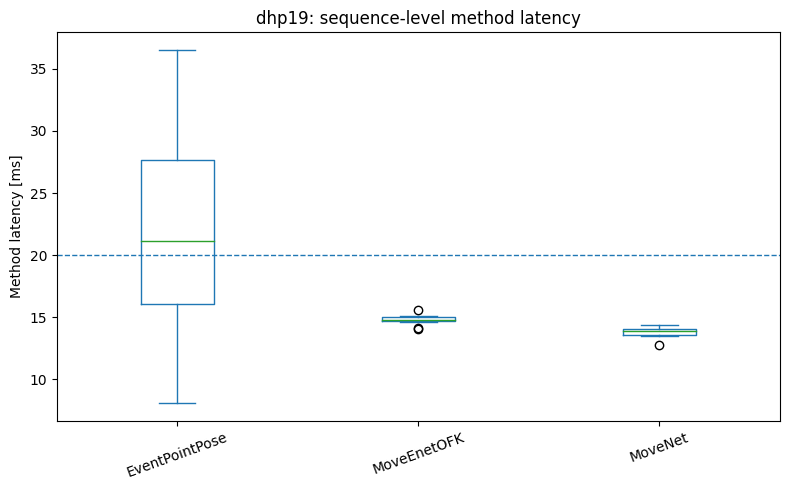

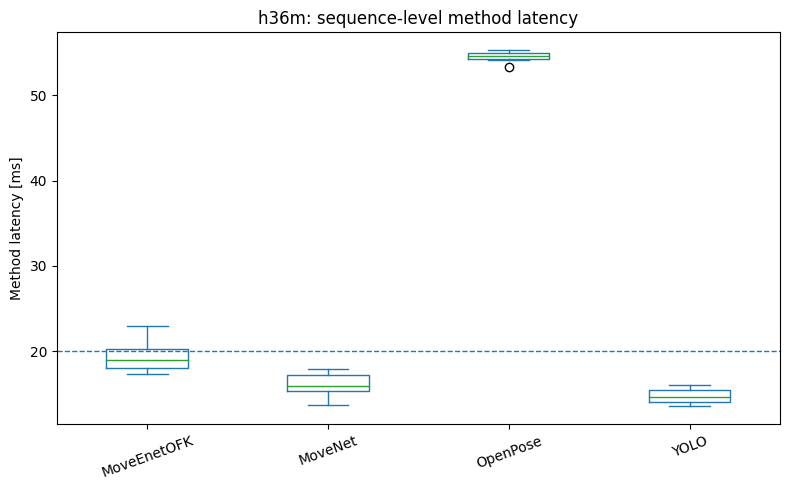

In [8]:
# Sequence-level method mean latency
for dataset, g in run_summary.groupby("dataset"):
    pivot=g.pivot(index="sample_id", columns="model", values="method_mean_ms")
    ax=pivot.plot(kind="box", figsize=(8,5), grid=False)
    ax.axhline(BUDGET_MS, linestyle="--", linewidth=1)
    ax.set_title(f"{dataset}: sequence-level method latency")
    ax.set_ylabel("Method latency [ms]")
    ax.set_xlabel("")
    plt.xticks(rotation=20)
    plt.tight_layout(); plt.show()


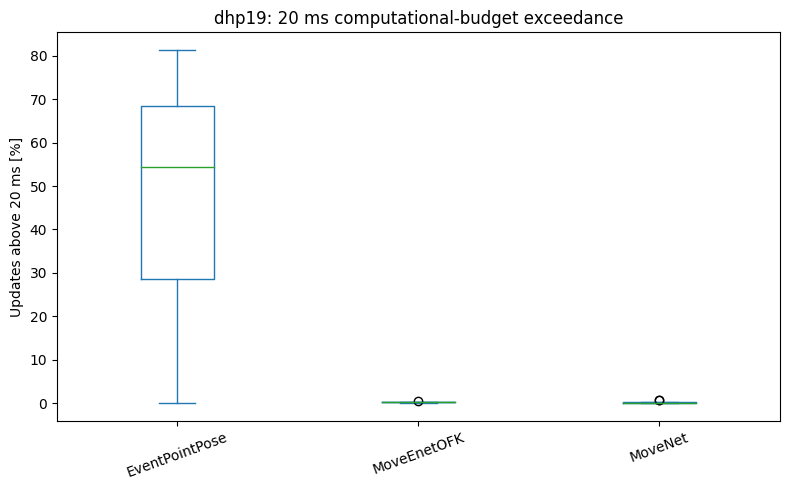

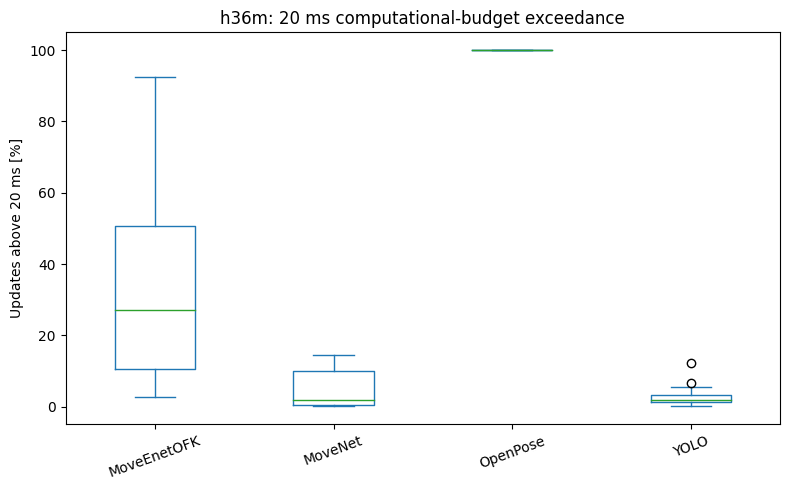

In [9]:
# Sequence-level percentage of updates above 20 ms
for dataset, g in run_summary.groupby("dataset"):
    pivot=g.pivot(index="sample_id", columns="model", values="budget_exceed_percent")
    ax=pivot.plot(kind="box", figsize=(8,5), grid=False)
    ax.set_title(f"{dataset}: 20 ms computational-budget exceedance")
    ax.set_ylabel("Updates above 20 ms [%]")
    ax.set_xlabel("")
    plt.xticks(rotation=20)
    plt.tight_layout(); plt.show()


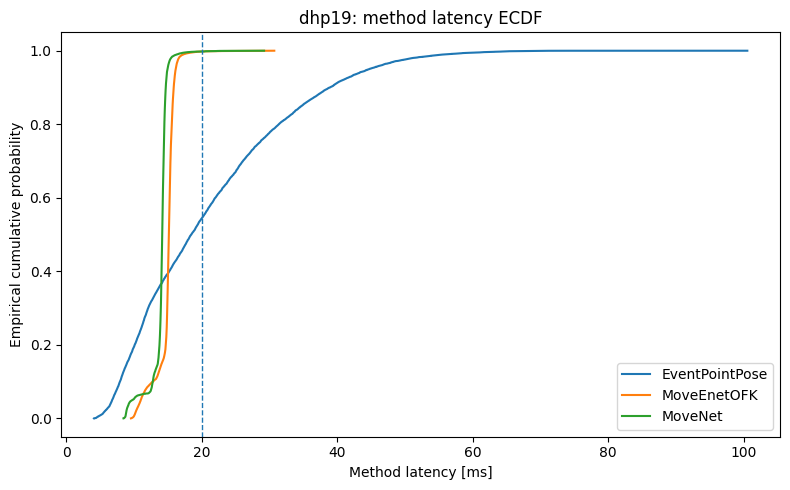

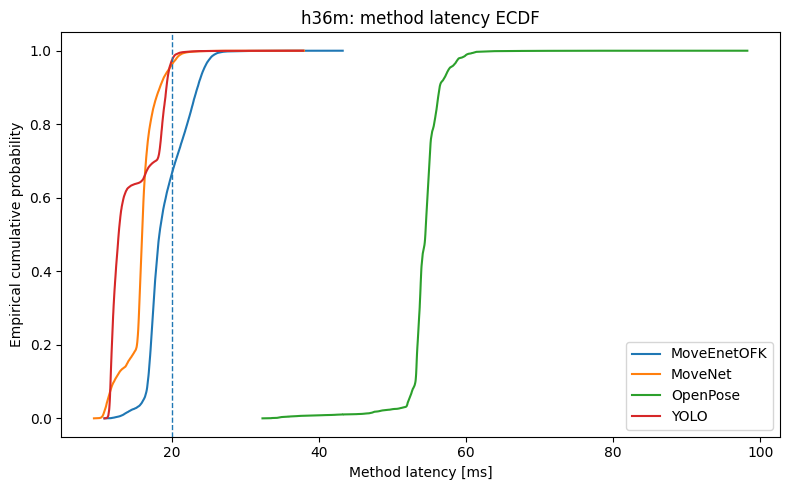

In [10]:
# Inference-level ECDF of method latency
def ecdf(values):
    x=np.sort(np.asarray(values,dtype=float)); x=x[np.isfinite(x)]
    return x, np.arange(1,len(x)+1)/len(x)

for dataset, g in inference_df.groupby("dataset"):
    fig, ax=plt.subplots(figsize=(8,5))
    for model, gm in g.groupby("model_display"):
        x,y=ecdf(gm["method_latency_ms"])
        ax.plot(x,y,label=model)
    ax.axvline(BUDGET_MS, linestyle="--", linewidth=1)
    ax.set_title(f"{dataset}: method latency ECDF")
    ax.set_xlabel("Method latency [ms]")
    ax.set_ylabel("Empirical cumulative probability")
    ax.legend(); plt.tight_layout(); plt.show()


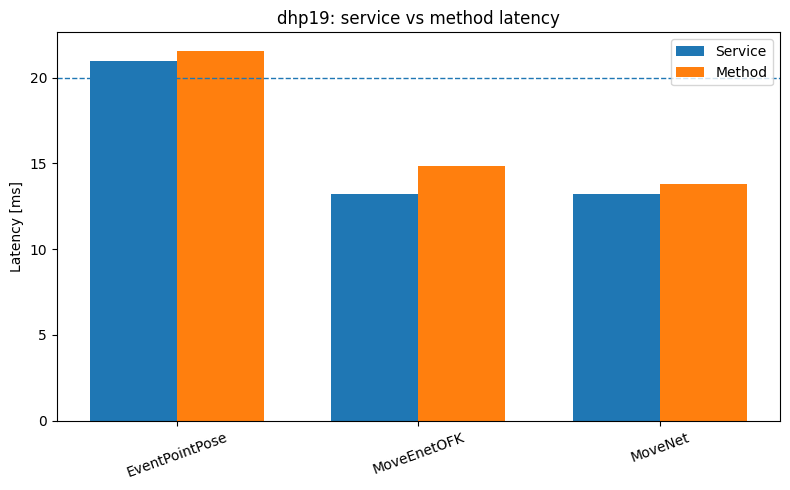

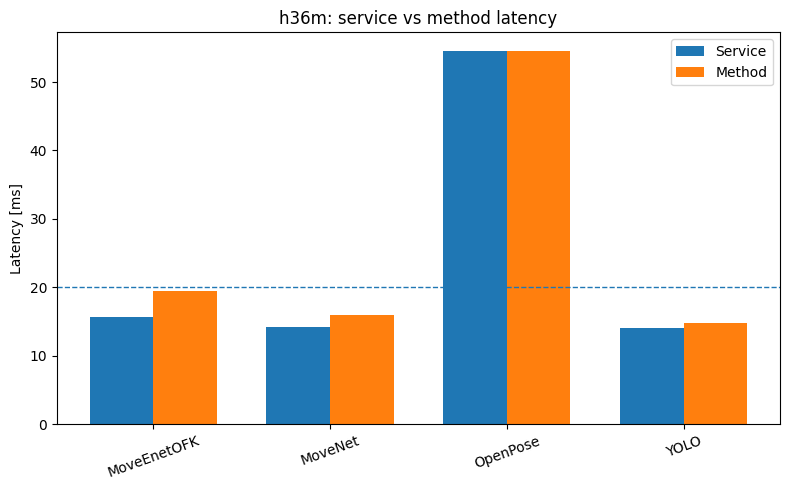

In [11]:
# Service vs method latency using sequence-level means
for dataset, g in run_summary.groupby("dataset"):
    models=list(g["model"].drop_duplicates())
    x=np.arange(len(models)); width=0.36
    service_vals=[g.loc[g["model"]==m,"service_mean_ms"].mean() for m in models]
    method_vals=[g.loc[g["model"]==m,"method_mean_ms"].mean() for m in models]
    fig,ax=plt.subplots(figsize=(8,5))
    ax.bar(x-width/2, service_vals, width, label="Service")
    ax.bar(x+width/2, method_vals, width, label="Method")
    ax.axhline(BUDGET_MS, linestyle="--", linewidth=1)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=20)
    ax.set_ylabel("Latency [ms]"); ax.set_title(f"{dataset}: service vs method latency")
    ax.legend(); plt.tight_layout(); plt.show()


## 8. Paired MoveNet vs MoveEnetOFK comparison

Paired at sequence level. Wilcoxon is exploratory and only run if SciPy is available.



dhp19
Paired sequences: 12
Mean paired difference   : 1.0131194617986414 ms
Median paired difference : 0.9714609598247339 ms
Min / max difference     : 0.31199076523702196 / 1.9850084956521759 ms
Wilcoxon statistic       : 0.0
Wilcoxon p-value         : 0.00048828125


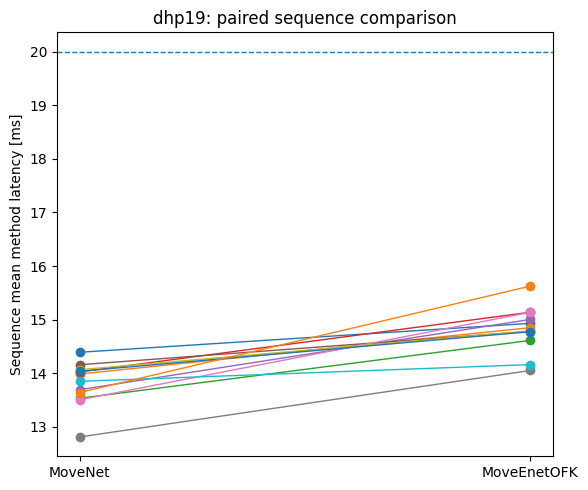


h36m
Paired sequences: 12
Mean paired difference   : 3.4042566209095626 ms
Median paired difference : 3.5472050109427276 ms
Min / max difference     : 1.8877532960229324 / 5.119125623872378 ms
Wilcoxon statistic       : 0.0
Wilcoxon p-value         : 0.00048828125


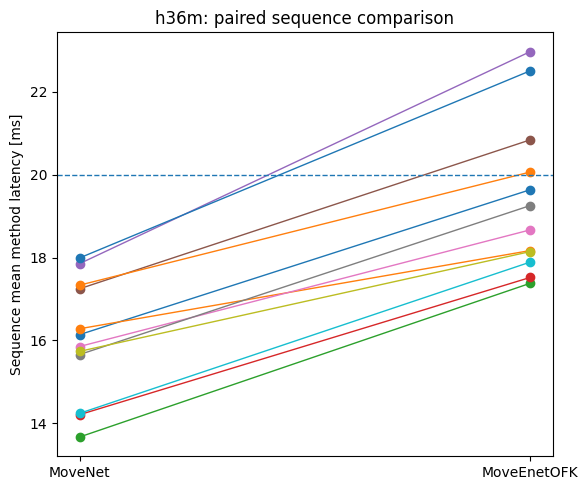

In [12]:
for dataset, g in run_summary.groupby("dataset"):
    p=g.pivot(index="sample_id", columns="model", values="method_mean_ms")
    if not {"MoveNet","MoveEnetOFK"}.issubset(p.columns):
        continue
    pair=p[["MoveNet","MoveEnetOFK"]].dropna()
    diff=pair["MoveEnetOFK"]-pair["MoveNet"]
    print("\n"+"="*70); print(dataset); print("="*70)
    print("Paired sequences:",len(pair))
    print("Mean paired difference   :",diff.mean(),"ms")
    print("Median paired difference :",diff.median(),"ms")
    print("Min / max difference     :",diff.min(),"/",diff.max(),"ms")
    if SCIPY_AVAILABLE and len(pair)>=2:
        try:
            res=stats.wilcoxon(pair["MoveEnetOFK"], pair["MoveNet"], alternative="two-sided")
            print("Wilcoxon statistic       :",res.statistic)
            print("Wilcoxon p-value         :",res.pvalue)
        except Exception as exc:
            print("Wilcoxon skipped:",exc)
    fig,ax=plt.subplots(figsize=(6,5))
    for _,row in pair.iterrows():
        ax.plot([0,1],[row["MoveNet"],row["MoveEnetOFK"]],marker="o",linewidth=1)
    ax.set_xticks([0,1]); ax.set_xticklabels(["MoveNet","MoveEnetOFK"])
    ax.set_ylabel("Sequence mean method latency [ms]")
    ax.set_title(f"{dataset}: paired sequence comparison")
    ax.axhline(BUDGET_MS, linestyle="--", linewidth=1)
    plt.tight_layout(); plt.show()


## 9. Order-position diagnostic

Checks for residual thermal/order effects. This is diagnostic, not a primary result.


,dataset,model,order_position,n_runs,mean_method_latency_ms,median_method_latency_ms
0,dhp19,EventPointPose,1,4,25.325882,22.076259
1,dhp19,EventPointPose,2,4,22.051493,24.940031
2,dhp19,EventPointPose,3,4,17.287206,15.524762
3,dhp19,MoveEnetOFK,1,4,14.744961,14.894013
4,dhp19,MoveEnetOFK,2,4,15.047232,14.892349
5,dhp19,MoveEnetOFK,3,4,14.676846,14.702104
6,dhp19,MoveNet,1,4,13.985606,14.007055
7,dhp19,MoveNet,2,4,13.944042,13.959982
8,dhp19,MoveNet,3,4,13.500033,13.574278
9,h36m,MoveEnetOFK,1,3,18.966598,18.168372


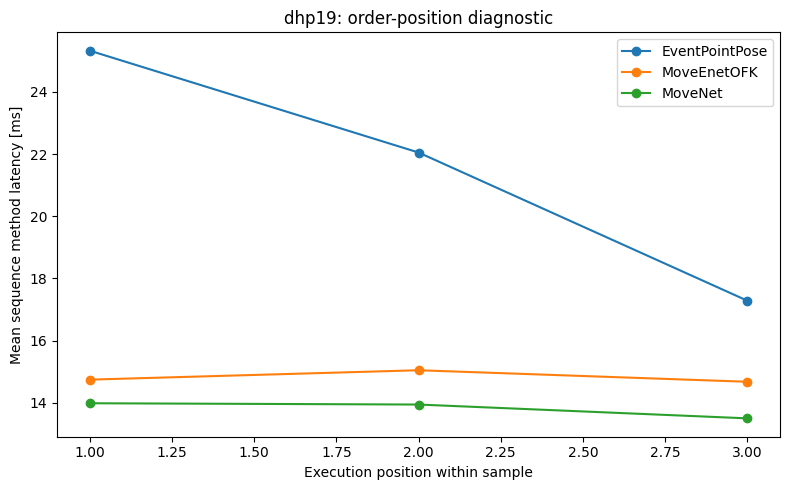

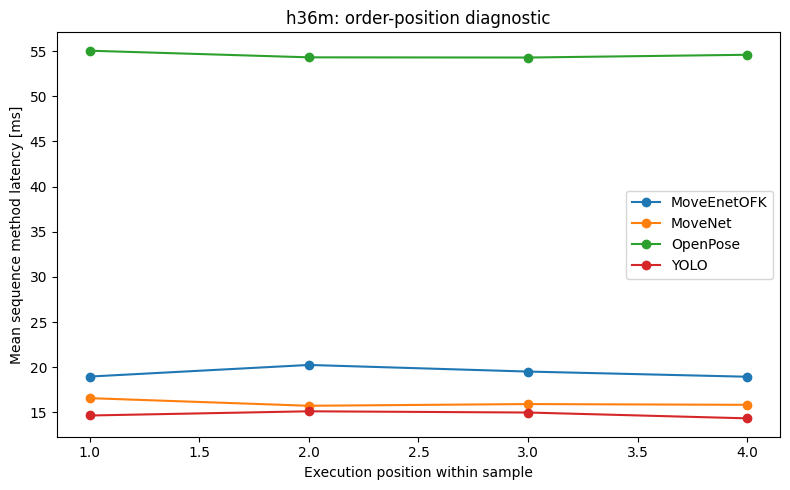

In [13]:
if "order_position" in run_summary.columns:
    tmp=run_summary.copy()
    tmp["order_position"]=pd.to_numeric(tmp["order_position"], errors="coerce")
    order_summary=(tmp.dropna(subset=["order_position"])
                   .groupby(["dataset","model","order_position"],as_index=False)
                   .agg(n_runs=("sample_id","count"),
                        mean_method_latency_ms=("method_mean_ms","mean"),
                        median_method_latency_ms=("method_mean_ms","median")))
    display(order_summary)
    for dataset,g in order_summary.groupby("dataset"):
        fig,ax=plt.subplots(figsize=(8,5))
        for model,gm in g.groupby("model"):
            gm=gm.sort_values("order_position")
            ax.plot(gm["order_position"],gm["mean_method_latency_ms"],marker="o",label=model)
        ax.set_title(f"{dataset}: order-position diagnostic")
        ax.set_xlabel("Execution position within sample")
        ax.set_ylabel("Mean sequence method latency [ms]")
        ax.legend(); plt.tight_layout(); plt.show()
else:
    print("order_position not present in run manifest.")


## 10. MoveEnetOFK dataset-time fusion delay

This is not wall-clock latency. Do not add it directly to `method_latency_ms`.


,dataset,n,mean_ms,median_ms,p95_ms,p99_ms
0,dhp19,11188,2.297805,2.2155,4.7340,5.007
1,h36m,30305,2.141649,2.0000,4.7472,5.000


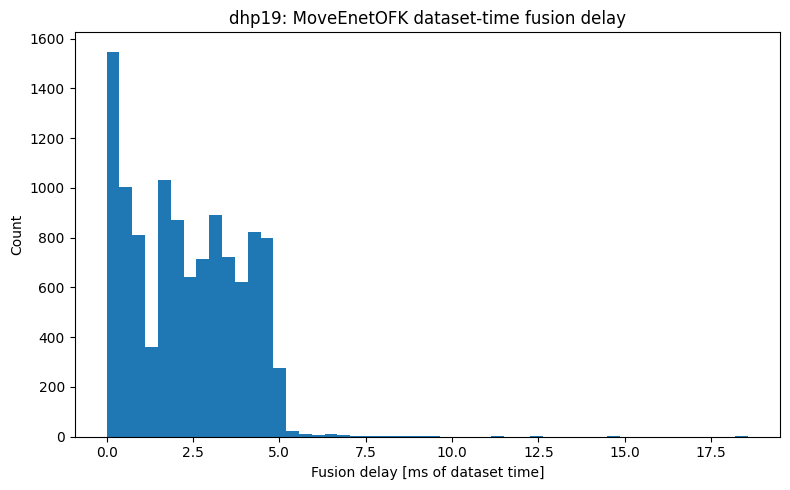

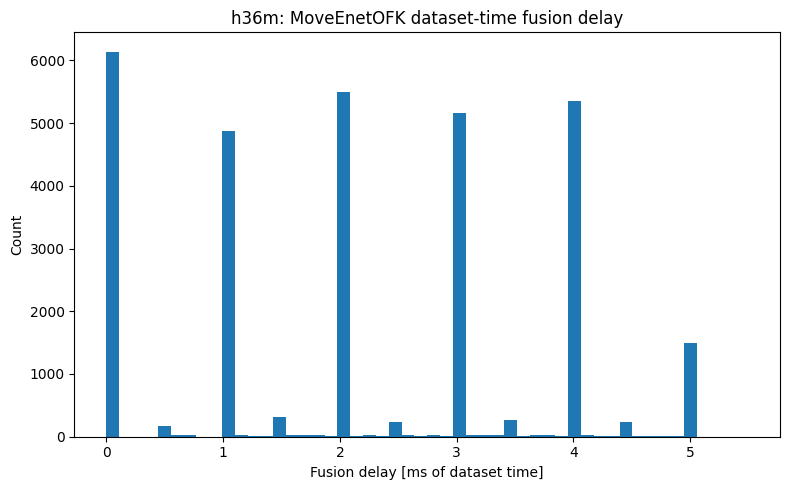

In [14]:
if "fusion_delay_ms" in inference_df.columns:
    fusion=inference_df[(inference_df["model_display"]=="MoveEnetOFK") & inference_df["fusion_delay_ms"].notna()].copy()
    if len(fusion):
        rows=[]
        for dataset,g in fusion.groupby("dataset"):
            s=metric_summary(g["fusion_delay_ms"])
            rows.append({"dataset":dataset,"n":s["n"],"mean_ms":s["mean"],"median_ms":s["median"],"p95_ms":s["p95"],"p99_ms":s["p99"]})
        display(pd.DataFrame(rows))
        for dataset,g in fusion.groupby("dataset"):
            fig,ax=plt.subplots(figsize=(8,5))
            ax.hist(g["fusion_delay_ms"].dropna(), bins=50)
            ax.set_title(f"{dataset}: MoveEnetOFK dataset-time fusion delay")
            ax.set_xlabel("Fusion delay [ms of dataset time]")
            ax.set_ylabel("Count"); plt.tight_layout(); plt.show()
else:
    print("No fusion_delay_ms column available.")


## 11. EventPointPose diagnostics

Expected nesting for valid `OK` outputs: `server_processing_ms <= service_latency_ms <= method_latency_ms`.


In [15]:
if "server_processing_ms" in inference_df.columns:
    epp=inference_df[(inference_df["model_display"]=="EventPointPose") & inference_df["server_processing_ms"].notna()].copy()
    if len(epp):
        rows=[]
        for dataset,g in epp.groupby("dataset"):
            a=metric_summary(g["server_processing_ms"]); b=metric_summary(g["service_latency_ms"]); c=metric_summary(g["method_latency_ms"])
            rows.append({
                "dataset":dataset,"n":len(g),
                "server_mean_ms":a["mean"],"server_p95_ms":a["p95"],
                "service_mean_ms":b["mean"],"service_p95_ms":b["p95"],
                "method_mean_ms":c["mean"],"method_p95_ms":c["p95"],
                "server_gt_service":int((g["server_processing_ms"]>g["service_latency_ms"]).sum()),
                "service_gt_method":int((g["service_latency_ms"]>g["method_latency_ms"]).sum()),
            })
        display(pd.DataFrame(rows))
    else:
        print("No EventPointPose steady-state rows found.")
else:
    print("server_processing_ms not present in loaded data.")


,dataset,n,server_mean_ms,server_p95_ms,service_mean_ms,service_p95_ms,method_mean_ms,method_p95_ms,server_gt_service,service_gt_method
0,dhp19,10673,6.740524,9.025069,20.569588,42.981978,21.133053,44.694504,0,0


## 12. Export analysis tables

Derived CSVs are written under `<session>/analysis/` and can always be regenerated from the raw latency files.


In [16]:
ANALYSIS_DIR=SESSION_ROOT/"analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
validation.to_csv(ANALYSIS_DIR/"latency_validation.csv", index=False)
run_summary.to_csv(ANALYSIS_DIR/"latency_run_summary.csv", index=False)
dataset_summary.to_csv(ANALYSIS_DIR/"latency_dataset_summary.csv", index=False)
inference_descriptive.to_csv(ANALYSIS_DIR/"latency_inference_descriptive.csv", index=False)
print("Saved analysis tables to:",ANALYSIS_DIR)
for p in sorted(ANALYSIS_DIR.glob("*.csv")):
    print(" -",p.name)


Saved analysis tables to: /data/MoveEnet_OFK_results/Latency/latency_50hz_main/analysis
 - latency_dataset_summary.csv
 - latency_inference_descriptive.csv
 - latency_run_summary.csv
 - latency_validation.csv


## Interpretation checklist for the paper

- Use `method_latency_ms` for the main cross-method comparison.
- Keep `service_latency_ms` as secondary because its exact implementation boundary differs across methods.
- Report mean, median, p95, p99, sequence count, retained inference count, and fraction above 20 ms.
- For MoveEnetOFK, keep wall-clock method latency separate from dataset-time fusion delay.
- For EventPointPose, treat `server_processing_ms` as an implementation diagnostic.
- In offline replay, describe `>20 ms` as the fraction of updates exceeding the nominal 20 ms computational budget associated with 50 Hz, not as a measured dropped-frame rate.
